0 - Bibliotecas e carga de dados

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)


# Carregando arquivos Parquet

DADOS_DIR = Path("../dados/consolidados")

#print(DADOS_DIR.resolve())
#print(list(DADOS_DIR.iterdir()))

mshl = pd.read_parquet(DADOS_DIR / "MSHL_consolidado.parquet")
cnes_lt = pd.read_parquet(DADOS_DIR / "LT_consolidado.parquet")
sih_rd = pd.read_parquet(DADOS_DIR / "RD_consolidado.parquet")

#Verificar se carregou corretamente
print("MSHL:", mshl.shape)
print("CNES-LT:", cnes_lt.shape)
print("SIH-RD:", sih_rd.shape)

MSHL: (2673, 9)
CNES-LT: (13079, 8)
SIH-RD: (696841, 20)


1. Internações por mês

In [3]:
sih_rd["ANO_MES"] = sih_rd["DT_INTER"].dt.to_period("M")

internacoes_mes = (
    sih_rd.groupby("ANO_MES")["N_AIH"]
    .nunique()
    .reset_index(name="internacoes")
)

internacoes_mes

,ANO_MES,internacoes
0,2022-03,1
1,2023-01,1
2,2023-02,1
3,2023-05,1
4,2023-06,1
5,2023-07,40
6,2023-08,360
7,2023-09,434
8,2023-10,1419
9,2023-11,3828


In [ ]:
Gráfico

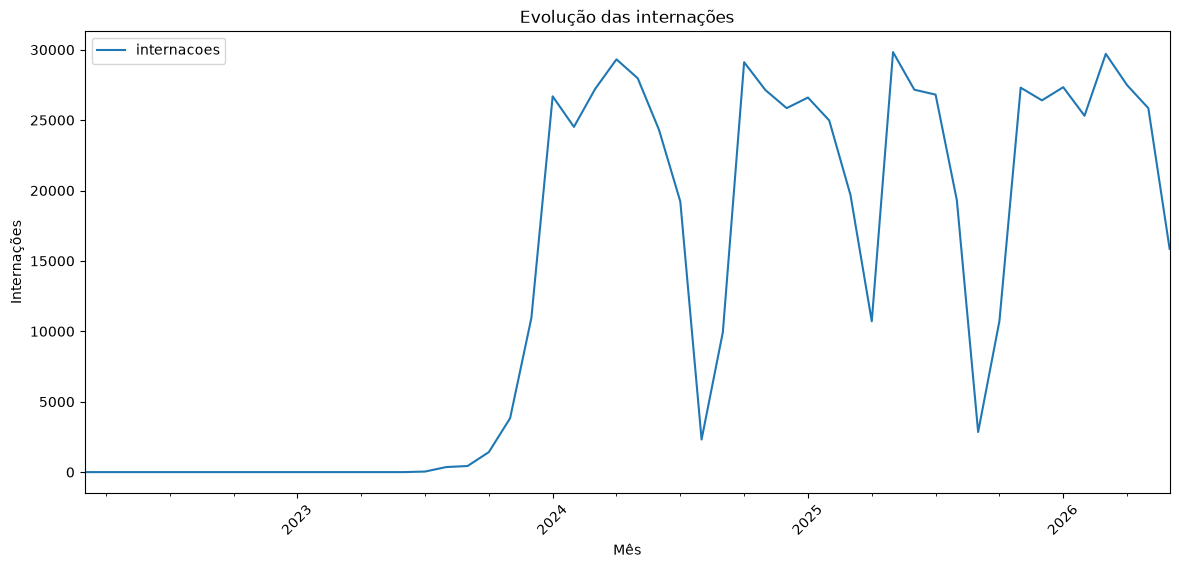

In [4]:
internacoes_mes.plot(
    x="ANO_MES",
    y="internacoes",
    figsize=(14, 6)
)

plt.title("Evolução das internações")
plt.xlabel("Mês")
plt.ylabel("Internações")
plt.xticks(rotation=45)
plt.show()

2. Tempo de permanência

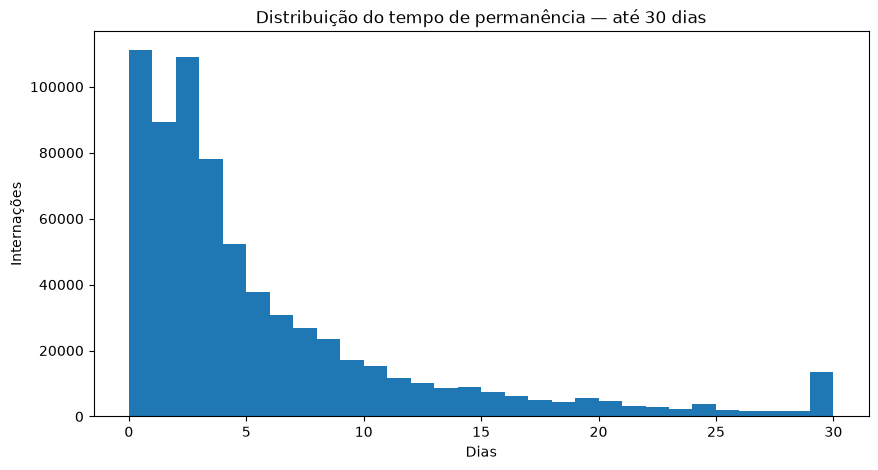

In [6]:
sih_rd["DIAS_PERM"].describe(
    percentiles=[.25, .50, .75, .90, .95, .99]
)

sih_rd["DIAS_PERM"].clip(upper=30).plot(
    kind="hist",
    bins=30,
    figsize=(10, 5)
)

plt.title("Distribuição do tempo de permanência — até 30 dias")
plt.xlabel("Dias")
plt.ylabel("Internações")
plt.show()

3. Permanência por estabelecimento

In [7]:
permanencia_cnes = (
    sih_rd.groupby("CNES")
    .agg(
        internacoes=("N_AIH", "nunique"),
        media=("DIAS_PERM", "mean"),
        mediana=("DIAS_PERM", "median"),
        p75=("DIAS_PERM", lambda x: x.quantile(.75)),
        p90=("DIAS_PERM", lambda x: x.quantile(.90)),
        dias_total=("DIAS_PERM", "sum")
    )
    .reset_index()
)

In [8]:
permanencia_cnes_filtrada = permanencia_cnes[
    permanencia_cnes["internacoes"] >= 30
].sort_values("mediana", ascending=False)

permanencia_cnes_filtrada.head(20)

,CNES,internacoes,media,mediana,p75,p90,dias_total
30,3983730,13724,9.81,7.00,13.00,22.00,134571
15,0001546,6064,10.08,7.00,15.00,27.00,82334
11,0000809,6145,6.35,6.00,9.00,12.00,39007
12,0000981,4292,9.45,6.00,15.00,27.00,42270
18,0147028,3485,8.94,6.00,13.00,23.00,31143
14,0001120,13194,7.51,6.00,11.00,18.00,99142
35,9671013,1640,7.53,6.00,10.00,14.00,12357
8,0000655,66804,7.70,6.00,11.00,17.00,514293
29,2802783,39456,7.67,4.00,11.00,20.00,302509
28,2777460,14740,5.31,4.00,7.00,11.00,78281
